In [744]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [745]:
TS  = 100
TD = -100

100 2499


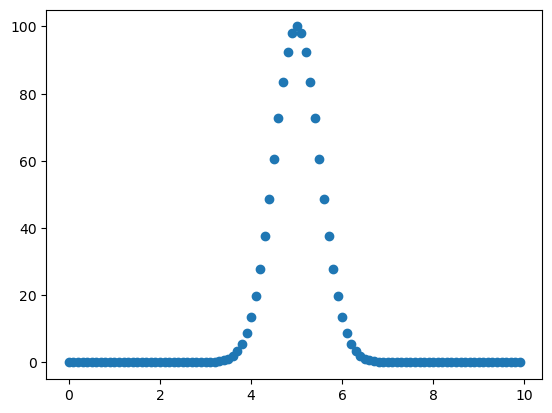

In [746]:
L = 10      # Lunghezza Sbarra
T = 10     # secondi

RIS = 100   # risoluzione spaziale
D = 1      # dipende dal materiale (HO USATO IL RAME)

DX = L / RIS
DT = 0.4 * DX**2 / D   # Condizioni di von neuman   

N = int(L / DX)
T = int(T / DT)

print(N,T)

C = np.zeros((N,T))
x = np.arange(N) * DX

mu    = L * 0.5     # sposta il picco: 0.3 = sinistra, 0.7 = destra  
sigma = L * 0.05    # picco stretto
T_max = 100         # temperatura massima del picco in gradi

C[:, 0] = T_max * np.exp(-((x - mu)**2) / (2 * sigma**2))
assert T > 0, "Tempo fisico troppo corto rispetto a DT!"
x = np.arange(C.shape[0]) * DX
plt.scatter(x,C[:,0])


In [ ]:
nu = DT/(DX**2)
print(nu)
for i in range(T):
    C[1:-1,1:] = C[1:-1, :-1] + nu*(C[2:,:-1] + C[:-2,:-1] - 2*C[1:-1,:-1])
    C[:, 0] = T_max * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Ricorda che il nu deve rispettare la condizione di von neuman
# (20.21) sul landau


0.4


In [748]:
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go

step_plot = 0.1
x = np.arange(C.shape[0]) * DX

fig = go.FigureWidget(
    data=[go.Scatter(x=x, y=C[:, 0], mode='lines', line=dict(color='red', width=2))]
)
fig.update_layout(
    xaxis_title='x (m)', yaxis_title='T (°C)',
    title='Diffusione del calore',
    yaxis=dict(range=[-120, 120])
)

slider = widgets.IntSlider(min=0, max=NSTEPS-1, step=step_plot, description='t:')
label = widgets.Label(value='t = 0.000 s')

def update(change):
    t_idx = change['new']
    fig.data[0].y = C[:, t_idx]
    label.value = f't = {t_idx * DT:.3f} s'

slider.observe(update, names='value')

display(fig, widgets.HBox([slider, label]))



FigureWidget({
    'data': [{'line': {'color': 'red', 'width': 2},
              'mode': 'lines',
              'type': 'scatter',
              'uid': 'c10f3e4f-58f4-4194-9a39-cfa29cbf99df',
              'x': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3,
                          1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7,
                          2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4. , 4.1,
                          4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1, 5.2, 5.3, 5.4, 5.5,
                          5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9,
                          7. , 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8. , 8.1, 8.2, 8.3,
                          8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9. , 9.1, 9.2, 9.3, 9.4, 9.5, 9.6, 9.7,
                          9.8, 9.9]),
              'y': array([1.92874985e-20, 1.39694394e-19, 9.72098502e-19, 6.49934797e-18,
        